<a href="https://colab.research.google.com/github/puneetbisarwal25/Deep-Learning-Basic/blob/main/autoencoder_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Importing Libraries

In [27]:
import torch
from torch import nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Step 2: Device Configuration

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


## Step 3: Loading the Dataset

In [29]:

tensor_transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=tensor_transform,
    download=True
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

## Step 4: Define the Autoencoder Model

In [30]:
class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Flatten image
        x = x.view(-1, 28 * 28)

        # Encode
        encoded = self.encoder(x)

        # Decode
        decoded = self.decoder(encoded)

        return decoded

## Step 5: Create Model



In [31]:
model = Autoencoder().to(device)

## Step 6: Loss Function and Optimizer

In [32]:
criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

## Step 6: Training the model and Plotting Training Loss

In [33]:
num_epochs = 5

for epoch in range(num_epochs):

    for images, _ in train_loader:

        images = images.to(device)

        # Forward pass
        outputs = model(images)

        # Flatten original images
        images = images.view(-1, 28 * 28)

        loss = criterion(outputs, images)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/5], Loss: 0.0319
Epoch [2/5], Loss: 0.0210
Epoch [3/5], Loss: 0.0190
Epoch [4/5], Loss: 0.0166
Epoch [5/5], Loss: 0.0159


## Step 7: Visualizing Original and Reconstructed Images

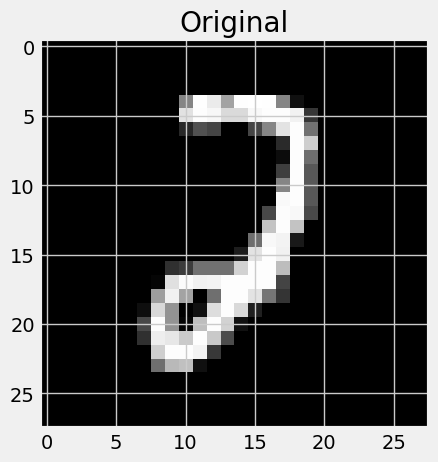

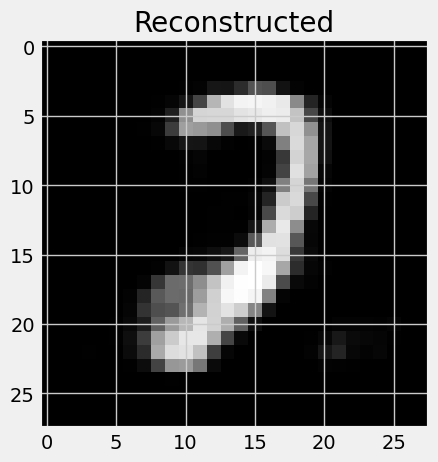

In [35]:
import matplotlib.pyplot as plt

examples = iter(train_loader)
images, _ = next(examples)

images = images.to(device)

reconstructed = model(images)

# Move to CPU
images = images.cpu()
reconstructed = reconstructed.cpu().detach()

# Show original image
plt.imshow(images[0].view(28,28), cmap="gray")
plt.title("Original")
plt.show()

# Show reconstructed image
plt.imshow(reconstructed[0].view(28,28), cmap="gray")
plt.title("Reconstructed")
plt.show()